### Data Quality Assessment

This notebook performs the initial assessment of the synthetic ISP customer dataset.

The objective is to evaluate data quality before applying any preprocessing or cleaning techniques.



### 1. Dataset Overview

### 2. Missing Values

### 3. Duplicate Records

### 4. Invalid Values

### 5. Categorical Features Inspection

### 6. Outlier Detection

### Conclusion

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [6]:
df = pd.read_csv("../data/synthetic_isp_customers_v2.csv")

### 1. Dataset Overview

 Let's inspect the dataset to understand its structure and basic information.

In [9]:
df.head()

,Customer_ID,Bandwidth_Mbps,Price_Per_Mbps,Monthly_Internet_Fee,Years_With_Company,Customer_Type,Company_Size,Strategic_Category,Strategic_Level,Has_VoIP,Monthly_VoIP_Fee,Has_Server,Server_Type,Monthly_Server_Fee,Support_Tickets_Last_Year,Downtime_Hours_Last_Year,Contract_Type
0,C00001,10,320000,3200000,4.2,Personal,Small,Normal,0,0,NaN,0,NaN,NaN,0,4.8,Monthly
1,C00002,10,385000,3850000,1.5,Personal,Small,Normal,0,0,NaN,0,NaN,NaN,3,4.8,Monthly
2,C00003,20,335000,6700000,0.9,Personal,Small,Normal,0,0,NaN,0,NaN,NaN,3,5.6,Monthly
3,C00004,50,315000,15750000,3.1,Personal,Small,Normal,0,0,NaN,0,NaN,NaN,2,1.3,Monthly
4,C00005,30,350000,10500000,2.2,Personal,Small,Normal,0,0,NaN,0,NaN,NaN,5,6.3,Monthly


### The first five rows provide an initial overview of the available features and their values.

In [11]:
df.shape

(3008, 17)

In [12]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 3008
Number of columns: 17


### The dataset contains customer information that will later be used for customer prioritization and segmentation.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3008 entries, 0 to 3007
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                3008 non-null   str    
 1   Bandwidth_Mbps             3008 non-null   int64  
 2   Price_Per_Mbps             3008 non-null   int64  
 3   Monthly_Internet_Fee       3008 non-null   int64  
 4   Years_With_Company         2983 non-null   float64
 5   Customer_Type              3008 non-null   str    
 6   Company_Size               3008 non-null   str    
 7   Strategic_Category         3008 non-null   str    
 8   Strategic_Level            3008 non-null   int64  
 9   Has_VoIP                   3008 non-null   int64  
 10  Monthly_VoIP_Fee           975 non-null    float64
 11  Has_Server                 3008 non-null   int64  
 12  Server_Type                621 non-null    str    
 13  Monthly_Server_Fee         621 non-null    float64
 14  Sup

### The output above shows the data types and the number of non-null values for each feature.

In [16]:
df.describe(include="all")

,Customer_ID,Bandwidth_Mbps,Price_Per_Mbps,Monthly_Internet_Fee,Years_With_Company,Customer_Type,Company_Size,Strategic_Category,Strategic_Level,Has_VoIP,Monthly_VoIP_Fee,Has_Server,Server_Type,Monthly_Server_Fee,Support_Tickets_Last_Year,Downtime_Hours_Last_Year,Contract_Type
count,3008,3008.000000,3008.000000,3.008000e+03,2983.000000,3008,3008,3008,3008.000000,3008.000000,9.750000e+02,3008.000000,621,6.210000e+02,3008.000000,2978.000000,3008
unique,3000,NaN,NaN,NaN,NaN,4,3,8,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,2
top,C00098,NaN,NaN,NaN,NaN,Personal,Small,Normal,NaN,NaN,NaN,NaN,VPS,NaN,NaN,NaN,Monthly
freq,2,NaN,NaN,NaN,NaN,1490,1879,1490,NaN,NaN,NaN,NaN,263,NaN,NaN,NaN,1873
mean,NaN,81.658910,291830.119681,2.040984e+07,5.041636,NaN,NaN,NaN,0.909242,0.324136,1.178733e+06,0.206449,NaN,1.144495e+07,3.131981,4.852250,NaN
std,NaN,87.565116,46204.099600,1.932928e+07,2.859388,NaN,NaN,NaN,1.101775,0.468129,4.956006e+05,0.404824,NaN,5.154818e+06,2.923057,2.603465,NaN
min,NaN,10.000000,200000.000000,3.200000e+06,0.200000,NaN,NaN,NaN,0.000000,0.000000,3.004930e+05,0.000000,NaN,2.055044e+06,0.000000,0.000000,NaN
25%,NaN,20.000000,250000.000000,6.000000e+06,2.500000,NaN,NaN,NaN,0.000000,0.000000,7.547390e+05,0.000000,NaN,6.963331e+06,0.000000,3.000000,NaN
50%,NaN,30.000000,300000.000000,9.900000e+06,5.100000,NaN,NaN,NaN,1.000000,0.000000,1.191149e+06,0.000000,NaN,1.179536e+07,2.000000,4.700000,NaN
75%,NaN,150.000000,325000.000000,3.450000e+07,7.500000,NaN,NaN,NaN,1.000000,1.000000,1.604922e+06,0.000000,NaN,1.581880e+07,5.000000,6.500000,NaN


### Interpretation

The descriptive statistics provide an overview of both numerical and categorical variables.

The dataset appears realistic and contains a mixture of continuous, categorical, and binary features that will require different preprocessing strategies.

# 2. Missing Values

Missing values are common in real-world datasets and should be identified before preprocessing.

In [19]:
missing = df.isnull().sum()

missing

Customer_ID                     0
Bandwidth_Mbps                  0
Price_Per_Mbps                  0
Monthly_Internet_Fee            0
Years_With_Company             25
Customer_Type                   0
Company_Size                    0
Strategic_Category              0
Strategic_Level                 0
Has_VoIP                        0
Monthly_VoIP_Fee             2033
Has_Server                      0
Server_Type                  2387
Monthly_Server_Fee           2387
Support_Tickets_Last_Year       0
Downtime_Hours_Last_Year       30
Contract_Type                   0
dtype: int64

In [20]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

Monthly_Server_Fee           79.355053
Server_Type                  79.355053
Monthly_VoIP_Fee             67.586436
Downtime_Hours_Last_Year      0.997340
Years_With_Company            0.831117
Customer_ID                   0.000000
Has_VoIP                      0.000000
Support_Tickets_Last_Year     0.000000
Has_Server                    0.000000
Strategic_Level               0.000000
Bandwidth_Mbps                0.000000
Strategic_Category            0.000000
Company_Size                  0.000000
Customer_Type                 0.000000
Monthly_Internet_Fee          0.000000
Price_Per_Mbps                0.000000
Contract_Type                 0.000000
dtype: float64

# 3. Duplicate Records

 Duplicate records may introduce bias during model training and should be identified.

In [23]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 8


In [24]:
df[df.duplicated()]

,Customer_ID,Bandwidth_Mbps,Price_Per_Mbps,Monthly_Internet_Fee,Years_With_Company,Customer_Type,Company_Size,Strategic_Category,Strategic_Level,Has_VoIP,Monthly_VoIP_Fee,Has_Server,Server_Type,Monthly_Server_Fee,Support_Tickets_Last_Year,Downtime_Hours_Last_Year,Contract_Type
3000,C00731,50,285000,14250000,2.2,Personal,Small,Normal,0,0,NaN,0,NaN,NaN,1,3.4,Monthly
3001,C00098,10,335000,3350000,6.3,Business,Large,Hospital,3,1,972656.0,1,Shared,15122774.0,8,8.6,Monthly
3002,C01245,10,380000,3800000,0.7,Personal,Small,Normal,0,0,NaN,0,NaN,NaN,3,3.4,Monthly
3003,C00852,30,300000,9000000,7.3,Business,Small,Small Business,1,1,1314166.0,0,NaN,NaN,6,5.6,Annual
3004,C01605,300,225000,67500000,1.0,Business,Medium,Small Business,1,1,773527.0,0,NaN,NaN,4,2.4,Monthly
3005,C02925,20,300000,6000000,8.0,Business,Medium,Small Business,1,0,NaN,0,NaN,NaN,2,2.4,Monthly
3006,C01154,20,300000,6000000,1.0,Personal,Small,Normal,0,0,NaN,0,NaN,NaN,2,2.1,Monthly
3007,C00602,50,335000,16750000,0.7,Business,Medium,Small Business,1,1,1348896.0,0,NaN,NaN,6,3.9,Monthly


 # 4. Invalid Values

 The ISP offers only predefined internet bandwidth plans. Any other bandwidth value is considered invalid.

In [26]:
valid_bandwidth = [10,20,30,50,100,150,200,300]

In [27]:
invalid_bandwidth = df[
    ~df["Bandwidth_Mbps"].isin(valid_bandwidth)
]

invalid_bandwidth

,Customer_ID,Bandwidth_Mbps,Price_Per_Mbps,Monthly_Internet_Fee,Years_With_Company,Customer_Type,Company_Size,Strategic_Category,Strategic_Level,Has_VoIP,Monthly_VoIP_Fee,Has_Server,Server_Type,Monthly_Server_Fee,Support_Tickets_Last_Year,Downtime_Hours_Last_Year,Contract_Type
1803,C01804,250,300000,6000000,6.3,Personal,Small,Normal,0,0,NaN,0,NaN,NaN,2,6.8,Monthly
2044,C02045,250,255000,25500000,8.8,Business,Medium,Small Business,1,1,1069952.0,0,NaN,NaN,6,10.8,Annual
2058,C02059,250,270000,13500000,3.8,Business,Small,Small Business,1,0,NaN,1,Dedicated,13728753.0,6,6.2,Monthly
2203,C02204,250,275000,27500000,0.2,Business,Medium,Small Business,1,1,469774.0,0,NaN,NaN,5,3.8,Monthly
2409,C02410,250,230000,34500000,2.5,Business,Small,Small Business,1,0,NaN,0,NaN,NaN,0,1.9,Monthly


## Interpretation

 The dataset contains a small number of invalid internet bandwidth values.

 Since the ISP offers only predefined bandwidth plans, these records will be corrected during the data cleaning stage.

# 5. Categorical Features Inspection

 Before cleaning the dataset, all categorical variables are inspected for inconsistent labels, typographical errors, and unexpected categories.

In [28]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

C:\Users\shiva\AppData\Local\Temp\ipykernel_12184\1797605437.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Index(['Customer_ID', 'Customer_Type', 'Company_Size', 'Strategic_Category',
       'Server_Type', 'Contract_Type'],
      dtype='str')

### The following categorical columns will be examined individually.

In [30]:
for col in categorical_columns:
    print("=" * 60)
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

Customer_ID
Customer_ID
C00098    2
C00602    2
C00731    2
C00852    2
C01154    2
         ..
C02996    1
C02997    1
C02998    1
C02999    1
C03000    1
Name: count, Length: 3000, dtype: int64

Customer_Type
Customer_Type
Personal      1490
Business      1256
Government     261
Goverment        1
Name: count, dtype: int64

Company_Size
Company_Size
Small     1879
Large      733
Medium     396
Name: count, dtype: int64

Strategic_Category
Strategic_Category
Normal            1490
Small Business     783
Government         262
Enterprise         132
University         117
ISP Partner        112
Hospital           110
SmallBusiness        2
Name: count, dtype: int64

Server_Type
Server_Type
NaN          2387
VPS           263
Shared        184
Dedicated     174
Name: count, dtype: int64

Contract_Type
Contract_Type
Monthly    1873
Annual     1135
Name: count, dtype: int64



 ## Interpretation

 Several categorical variables contain inconsistent labels caused by differences in capitalization or spelling.

 These inconsistencies will be standardized during the data cleaning stage.

 # 6. Outlier Detection

 Outliers are inspected to identify unusual observations.

 However, in a business environment, extreme values may represent high-value customers rather than erroneous data.

 Therefore, outliers will be investigated before deciding whether any action is required.

In [31]:
numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

Index(['Bandwidth_Mbps', 'Price_Per_Mbps', 'Monthly_Internet_Fee',
       'Years_With_Company', 'Strategic_Level', 'Has_VoIP', 'Monthly_VoIP_Fee',
       'Has_Server', 'Monthly_Server_Fee', 'Support_Tickets_Last_Year',
       'Downtime_Hours_Last_Year'],
      dtype='str')

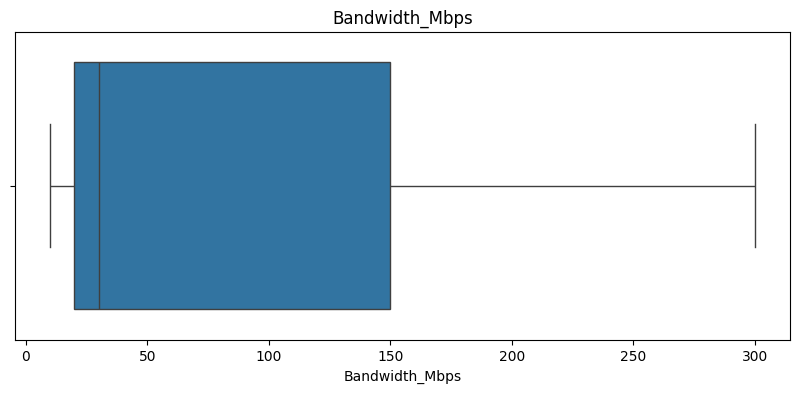

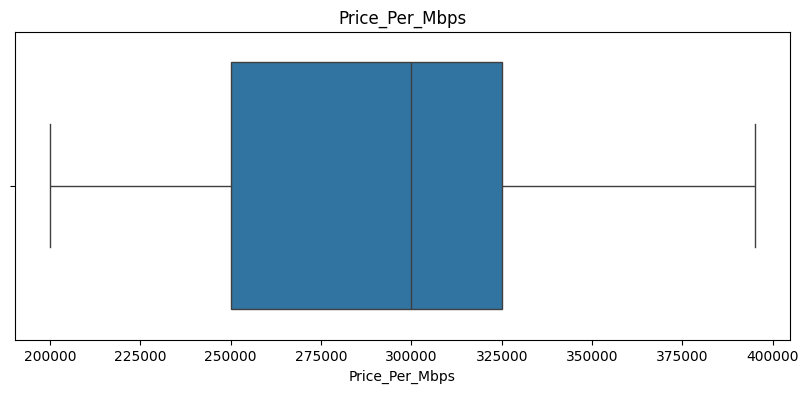

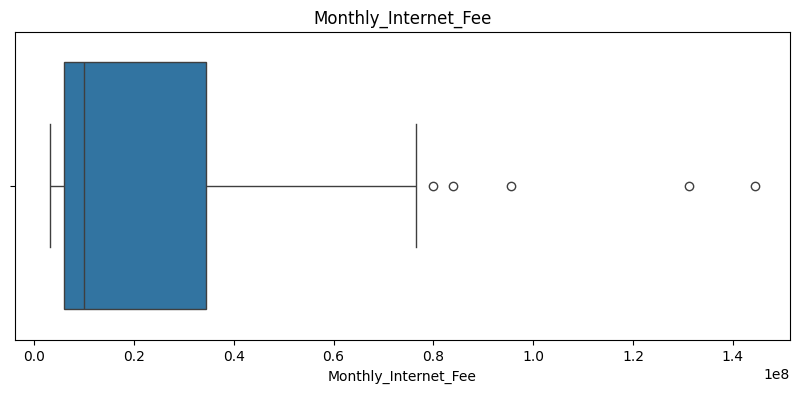

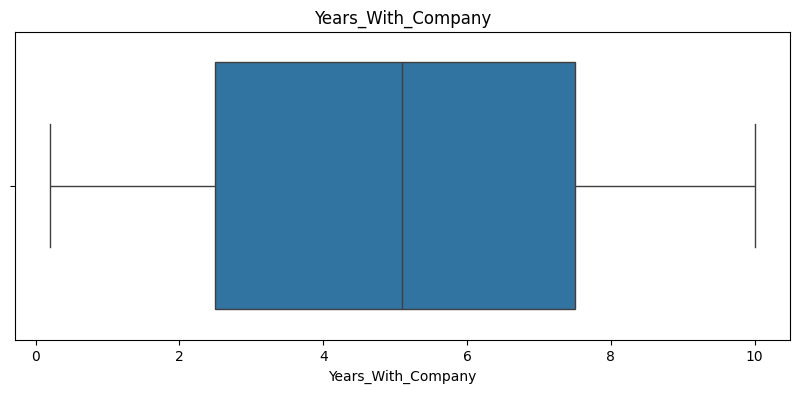

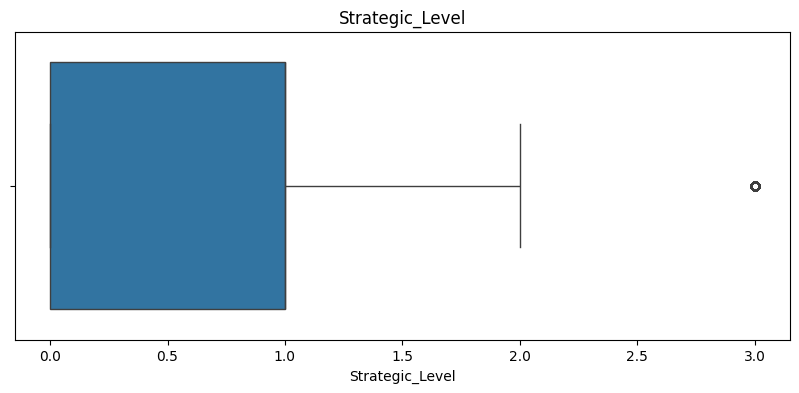

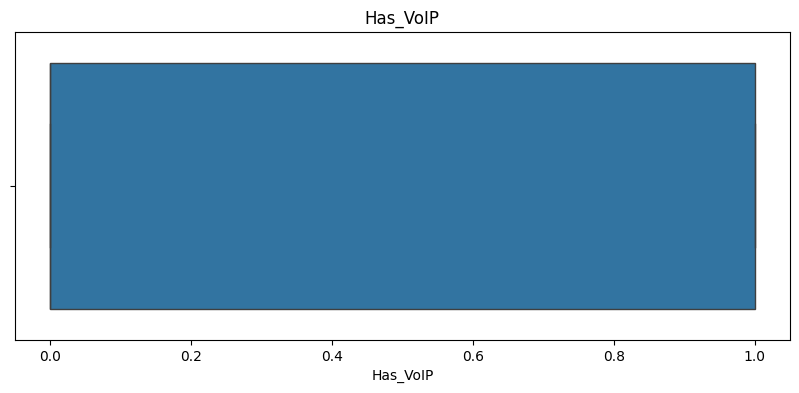

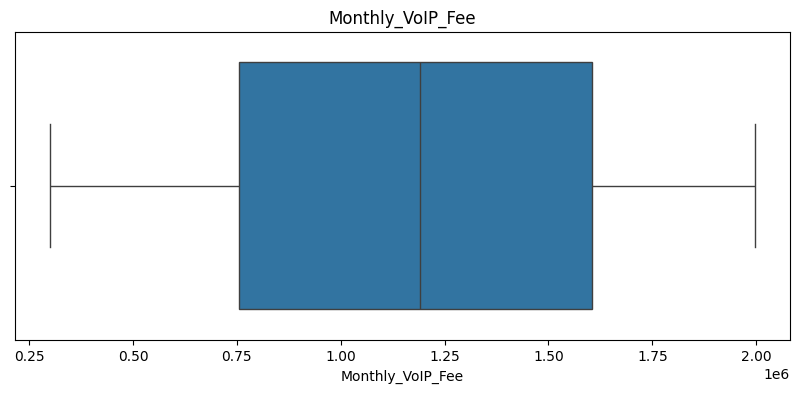

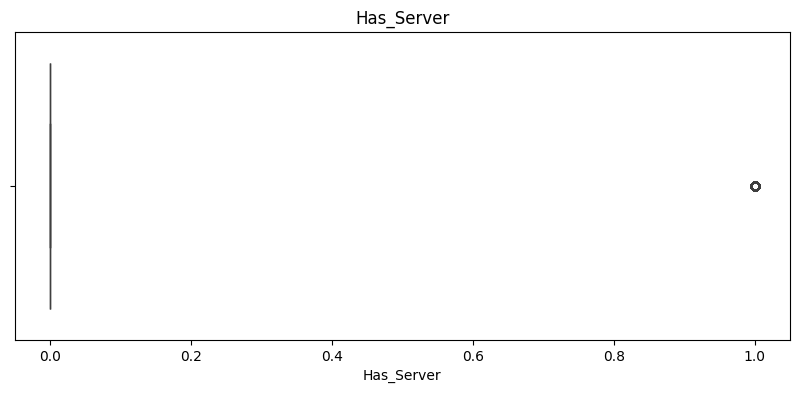

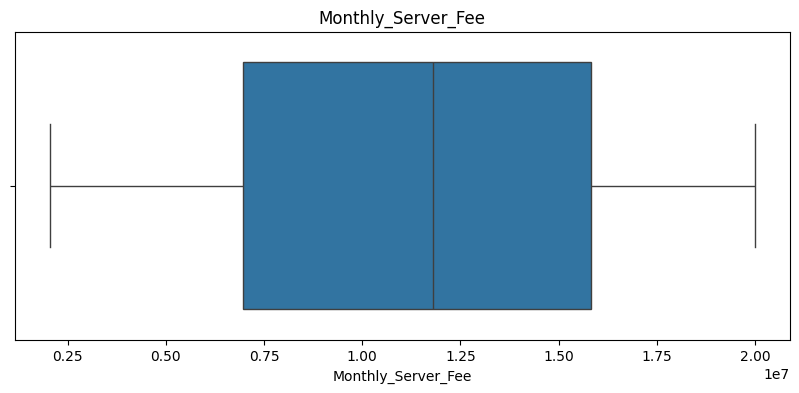

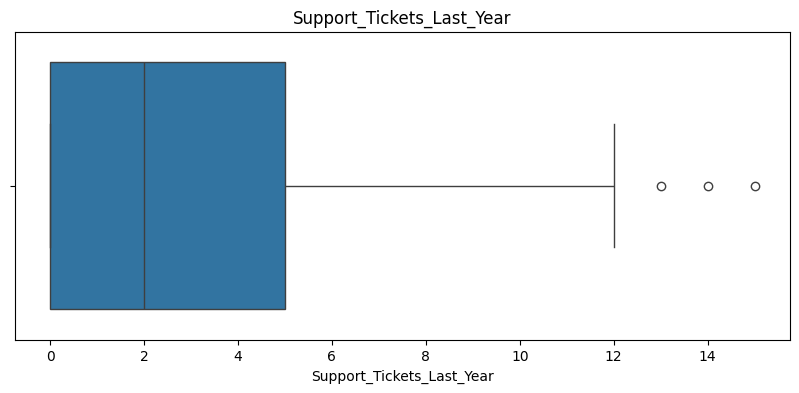

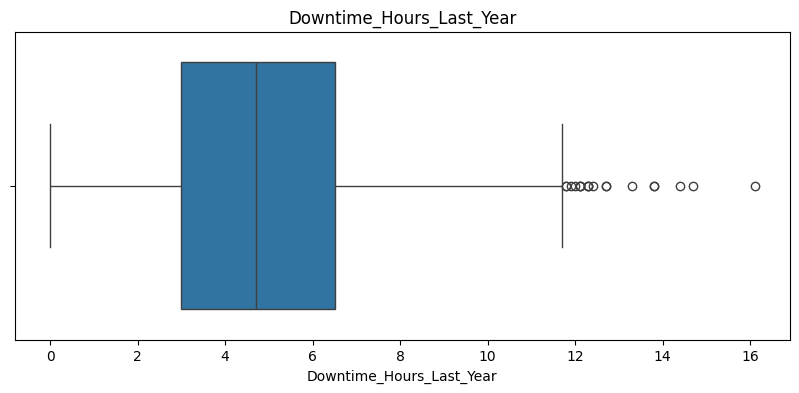

In [32]:
for col in numerical_columns:

    plt.figure(figsize=(10,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [34]:
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

Bandwidth_Mbps: 0 outliers
Price_Per_Mbps: 0 outliers
Monthly_Internet_Fee: 5 outliers
Years_With_Company: 0 outliers
Strategic_Level: 484 outliers
Has_VoIP: 0 outliers
Monthly_VoIP_Fee: 0 outliers
Has_Server: 621 outliers
Monthly_Server_Fee: 0 outliers
Support_Tickets_Last_Year: 3 outliers
Downtime_Hours_Last_Year: 19 outliers


 ### Interpretation

 Several numerical variables contain statistical outliers.

 These observations are **not automatically considered errors**, since high-value enterprise customers naturally generate significantly higher revenue and service usage.

 Outlier treatment decisions will therefore be based on business context rather than statistical criteria alone.

 # Conclusion

 The initial assessment identified several data quality issues:

- Missing values
 - Duplicate records
 - Invalid bandwidth values
 - Inconsistent categorical labels
 - Statistical outliers

 These findings will guide the data cleaning process in the next notebook.